# MNIST One-Class / One-vs-Rest Outlier Detection

**Goal:** treat one digit as **normal** and all others as **outliers**, then train a detector (typically on normal-only) and evaluate on a mixed test set.

**Conventions**
- `y = 0` → normal
- `y = 1` → outlier
- higher anomaly score → more anomalous

**Make it modifiable**
- Set `NORMAL_DIGITS = [0]` (or any digit list) to change what is "normal".


> Ensemble = standardized (z-scored on validation) average of base detector scores.

In [ ]:
!pip -q install -r ../requirements.txt

In [2]:
import sys
sys.path.append('..')
from common.utils import *

## Data

In [3]:
SEED = 42
import os
import numpy as np
from sklearn.model_selection import train_test_split

import torch
from torchvision import datasets, transforms

from common.utils import set_global_seed

set_global_seed(SEED)

# --- Config ---
NORMAL_DIGITS = [0]          # <-- change this to compare different "normal" digits
SEED = 42
DATA_DIR = "./data"
VAL_SIZE = 0.2               # validation split from training pool
MAX_TRAIN_NORMAL = 20000     # cap for speed; set None for full
MAX_VAL_TOTAL = 8000         # cap for speed; set None for full
MAX_TEST_TOTAL = 10000       # cap for speed; set None for full

# --- Load MNIST ---
tfm = transforms.ToTensor()
train_full = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=tfm)
test_full  = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=tfm)

def to_numpy(ds):
    X = ds.data.numpy().astype(np.float32) / 255.0  # [N, 28, 28]
    y = ds.targets.numpy().astype(int)
    return X, y

Xtr_all, ytr_all = to_numpy(train_full)
Xte_all, yte_all = to_numpy(test_full)

normal_mask = np.isin(ytr_all, NORMAL_DIGITS)
X_normal = Xtr_all[normal_mask]
y_normal = ytr_all[normal_mask]  # unused beyond checks

# Train/val split on normal-only pool
X_train_n, X_val_n = train_test_split(X_normal, test_size=VAL_SIZE, random_state=SEED, shuffle=True)

if MAX_TRAIN_NORMAL is not None:
    X_train_n = X_train_n[:MAX_TRAIN_NORMAL]
if MAX_VAL_TOTAL is not None:
    X_val_n = X_val_n[:MAX_VAL_TOTAL]

# Build validation mix: normal + outliers (for threshold selection / AUROC sanity)
# We'll sample outliers from training split that are NOT normal digits.
out_mask = ~np.isin(ytr_all, NORMAL_DIGITS)
X_out_pool = Xtr_all[out_mask]
y_out_pool = ytr_all[out_mask]

# Match validation outlier count to normal count (balanced val for stable thresholding)
n_val_norm = len(X_val_n)
n_val_out = min(len(X_out_pool), n_val_norm)
X_val_out = X_out_pool[:n_val_out]

X_val = np.concatenate([X_val_n, X_val_out], axis=0)
y_val = np.concatenate([np.zeros(len(X_val_n), dtype=int), np.ones(len(X_val_out), dtype=int)], axis=0)

# Test mix: all test digits, mapped to normal vs outlier
y_test = (~np.isin(yte_all, NORMAL_DIGITS)).astype(int)
X_test = Xte_all

# Optional caps
if MAX_TEST_TOTAL is not None:
    X_test = X_test[:MAX_TEST_TOTAL]
    y_test = y_test[:MAX_TEST_TOTAL]

# Flattened view for classical models
X_train_flat = X_train_n.reshape(len(X_train_n), -1)
X_val_flat   = X_val.reshape(len(X_val), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

print("Normal digits:", NORMAL_DIGITS)
print("Train normals:", X_train_n.shape, "Val mix:", X_val.shape, "Test mix:", X_test.shape)
print("Test outlier rate:", float(y_test.mean()))


Normal digits: [0]
Train normals: (4738, 28, 28) Val mix: (2370, 28, 28) Test mix: (10000, 28, 28)
Test outlier rate: 0.902


## Base detectors (kNN + GMM + OCSVM)

In [4]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.svm import OneClassSVM

# --- kNN ---
K = 10
nn = NearestNeighbors(n_neighbors=K, metric="euclidean", n_jobs=-1)
nn.fit(X_train_flat)
scores_val_knn = nn.kneighbors(X_val_flat, return_distance=True)[0].mean(axis=1)
scores_test_knn = nn.kneighbors(X_test_flat, return_distance=True)[0].mean(axis=1)

# --- PCA for GMM + OCSVM ---
PCA_DIM = 50
pca = PCA(n_components=PCA_DIM, random_state=SEED)
X_train_z = pca.fit_transform(X_train_flat)
X_val_z   = pca.transform(X_val_flat)
X_test_z  = pca.transform(X_test_flat)

# --- GMM ---
N_COMPONENTS = 10
gmm = GaussianMixture(n_components=N_COMPONENTS, covariance_type="diag", random_state=SEED, max_iter=200, reg_covar=1e-6)
gmm.fit(X_train_z)
scores_val_gmm = -gmm.score_samples(X_val_z)
scores_test_gmm = -gmm.score_samples(X_test_z)

# --- OCSVM ---
NU = 0.05
oc = OneClassSVM(kernel="rbf", nu=NU, gamma="scale")
oc.fit(X_train_z)
scores_val_oc = -oc.decision_function(X_val_z).ravel()
scores_test_oc = -oc.decision_function(X_test_z).ravel()

# Stack
S_val = np.vstack([scores_val_knn, scores_val_gmm, scores_val_oc]).T
S_test = np.vstack([scores_test_knn, scores_test_gmm, scores_test_oc]).T

print("Base score matrix shapes:", S_val.shape, S_test.shape)


Base score matrix shapes: (2370, 3) (10000, 3)


## Score standardization + aggregation

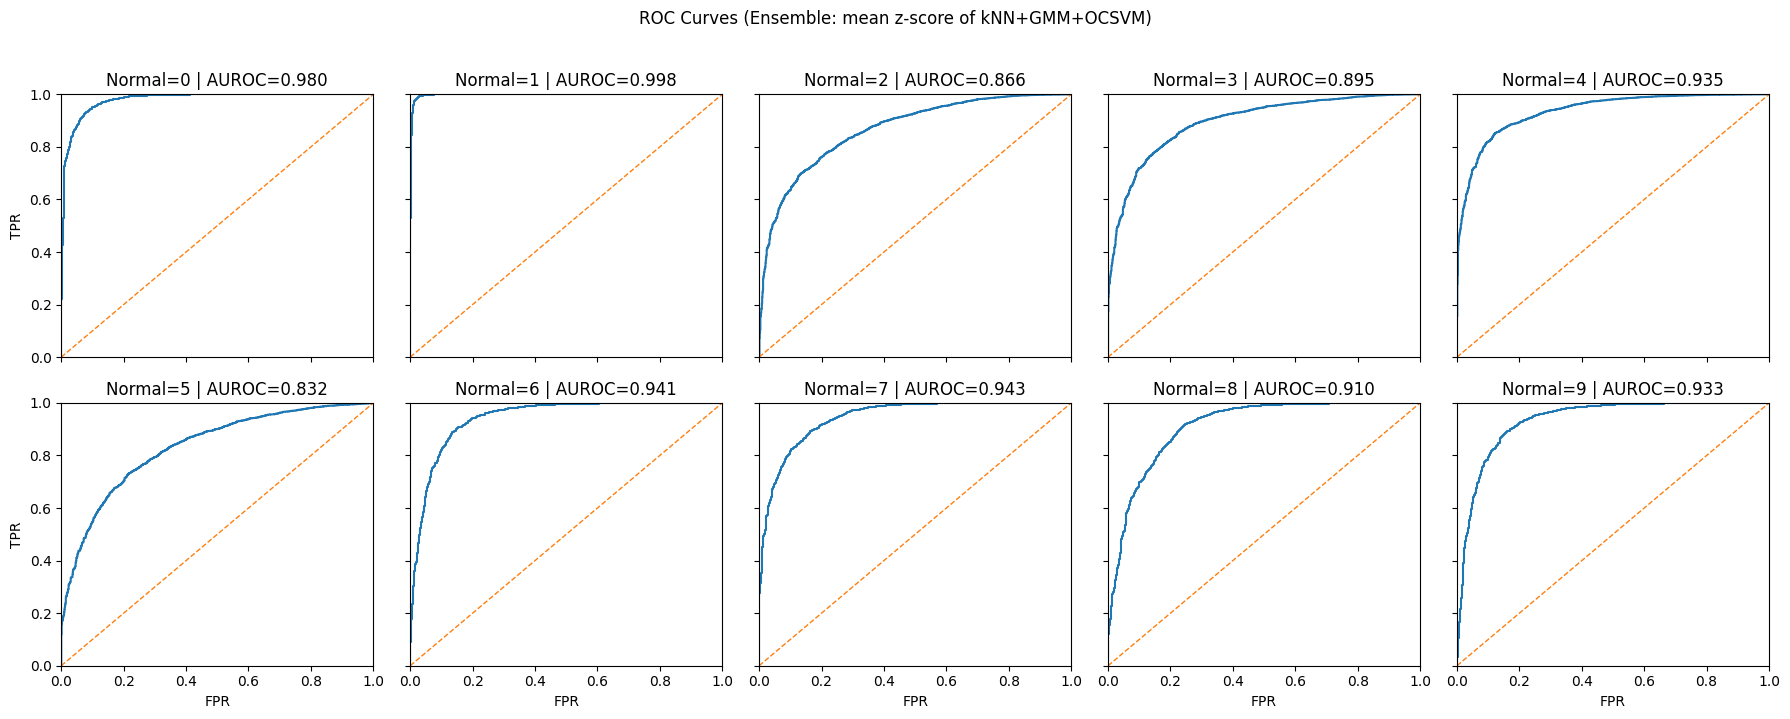

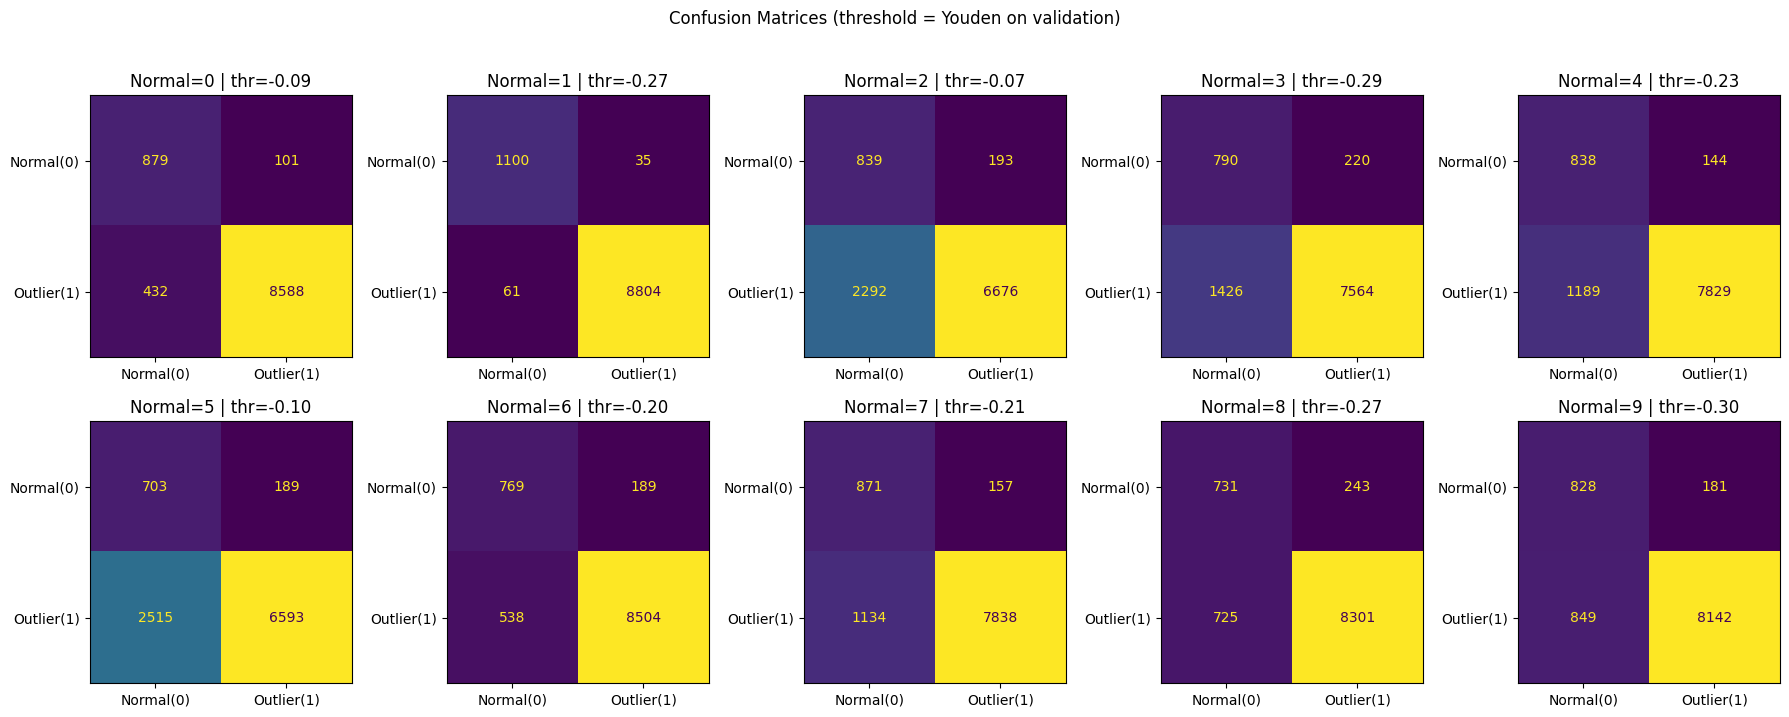

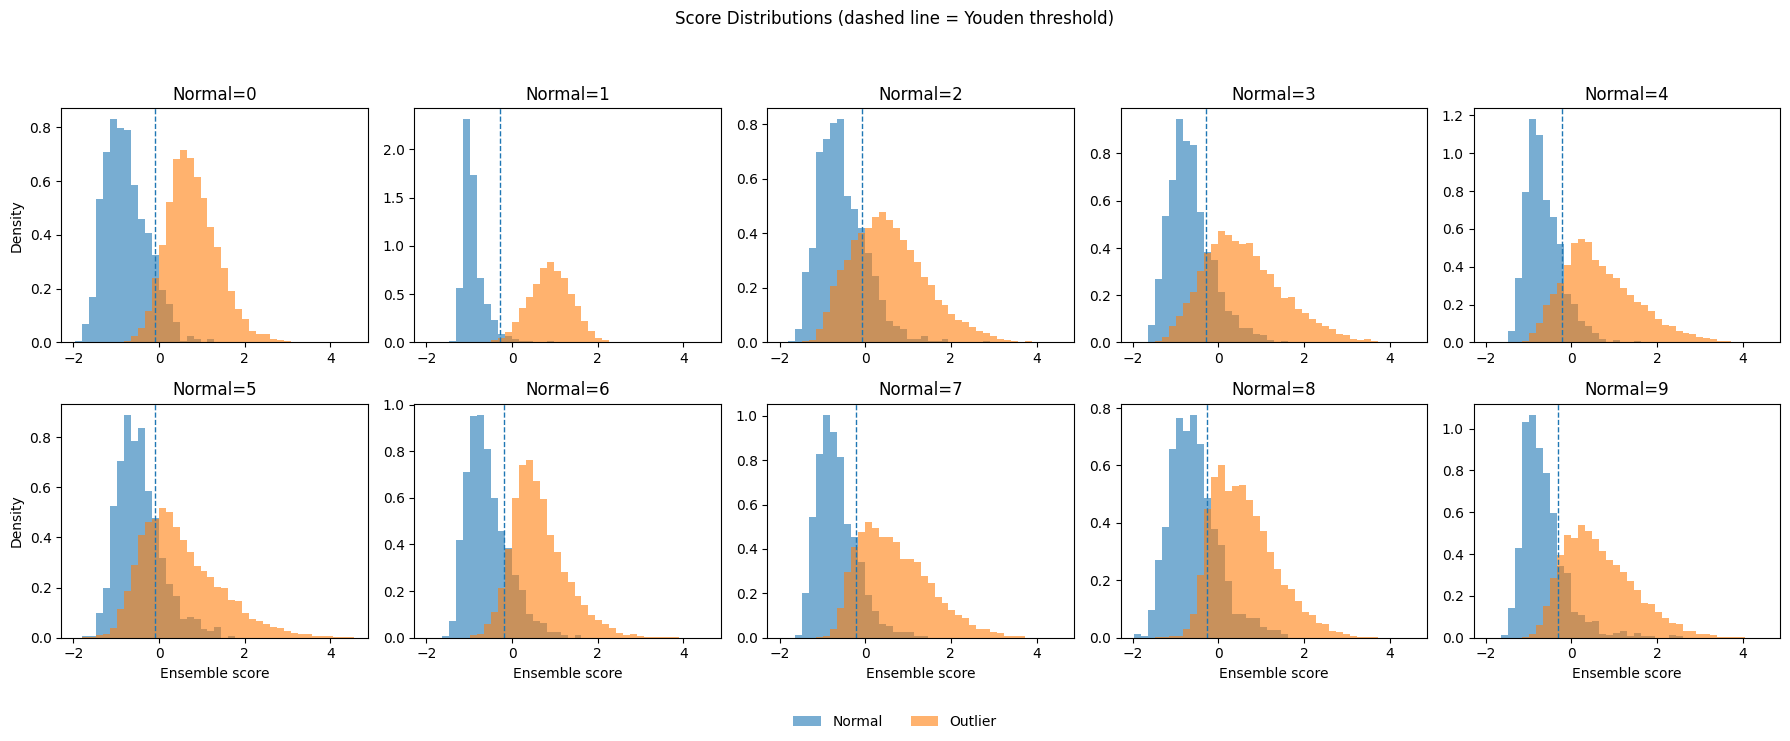

In [5]:
# import numpy as np
# from common.utils import compute_auroc, plot_roc_curve, choose_threshold_youden, confusion_at_threshold, plot_confusion_matrix, plot_score_hist

# # z-score using validation stats per detector
# mu = S_val.mean(axis=0, keepdims=True)
# sd = S_val.std(axis=0, keepdims=True) + 1e-8
# S_val_z = (S_val - mu) / sd
# S_test_z = (S_test - mu) / sd

# # aggregate (mean)
# scores_val = S_val_z.mean(axis=1)
# scores_test = S_test_z.mean(axis=1)

# auroc = compute_auroc(y_test, scores_test)
# print(f"Test AUROC (Ensemble: mean z-score of kNN+GMM+OCSVM): {auroc:.4f}")

# plot_roc_curve(y_test, scores_test, title="Ensemble (kNN+GMM+OCSVM)")
# plot_score_hist(scores_test, y_test, title="Ensemble score distribution")

# thr = choose_threshold_youden(y_val, scores_val)
# cm, parts = confusion_at_threshold(y_test, scores_test, thr)
# print("Threshold (Youden on val):", thr)
# print(parts)
# plot_confusion_matrix(cm, title=f"Ensemble Confusion Matrix (thr={thr:.4f})")

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# ----------------------------
# Config (matches your notebook)
# ----------------------------
SEED = 42
VAL_SIZE = 0.2
DATA_DIR = "./data"
MAX_TRAIN_NORMAL = 20000
MAX_VAL_TOTAL = 8000
MAX_TEST_TOTAL = 10000

# Detector params (matches your notebook)
K = 10
PCA_DIM = 50
N_COMPONENTS = 10

# ----------------------------
# Load MNIST once
# ----------------------------
from torchvision import datasets, transforms
tfm = transforms.ToTensor()
train_full = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=tfm)
test_full  = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=tfm)

def to_numpy(ds):
    X = ds.data.numpy().astype(np.float32) / 255.0  # [N, 28, 28]
    y = ds.targets.numpy().astype(int)
    return X, y

Xtr_all, ytr_all = to_numpy(train_full)
Xte_all, yte_all = to_numpy(test_full)

rng = np.random.default_rng(SEED)

# ----------------------------
# Helpers
# ----------------------------
def choose_threshold_youden(y_true, scores):
    # y_true: 0=normal, 1=outlier; scores: higher => more outlier-ish
    fpr, tpr, thr = roc_curve(y_true, scores)
    j = tpr - fpr
    return thr[np.argmax(j)]

def run_one(normal_digit: int):
    """
    Returns:
      - fpr, tpr, auroc
      - cm (2x2)
      - scores_test, y_test (for score dist plot)
      - thr (chosen on validation via Youden)
    """
    NORMAL_DIGITS = [normal_digit]

    # --- Build normal-only training pool from train set ---
    normal_mask = np.isin(ytr_all, NORMAL_DIGITS)
    X_normal = Xtr_all[normal_mask]

    # Train/val split on normal-only pool
    X_train_n, X_val_n = train_test_split(
        X_normal, test_size=VAL_SIZE, random_state=SEED, shuffle=True
    )

    if MAX_TRAIN_NORMAL is not None:
        X_train_n = X_train_n[:MAX_TRAIN_NORMAL]
    if MAX_VAL_TOTAL is not None:
        X_val_n = X_val_n[:MAX_VAL_TOTAL]

    # --- Build validation mix: normals + sampled outliers from train set ---
    out_mask = ~np.isin(ytr_all, NORMAL_DIGITS)
    X_out_pool = Xtr_all[out_mask]

    n_val_norm = len(X_val_n)
    n_val_out = min(len(X_out_pool), n_val_norm)
    # shuffle outlier pool so val isn't biased by MNIST ordering
    out_idx = rng.permutation(len(X_out_pool))[:n_val_out]
    X_val_out = X_out_pool[out_idx]

    X_val = np.concatenate([X_val_n, X_val_out], axis=0)
    y_val = np.concatenate([
        np.zeros(len(X_val_n), dtype=int),
        np.ones(len(X_val_out), dtype=int)
    ], axis=0)

    # --- Test mix: full test set, label as outlier if not normal digit ---
    X_test = Xte_all
    y_test = (~np.isin(yte_all, NORMAL_DIGITS)).astype(int)

    if MAX_TEST_TOTAL is not None:
        X_test = X_test[:MAX_TEST_TOTAL]
        y_test = y_test[:MAX_TEST_TOTAL]

    # Flatten for classical models
    X_train_flat = X_train_n.reshape(len(X_train_n), -1)
    X_val_flat   = X_val.reshape(len(X_val), -1)
    X_test_flat  = X_test.reshape(len(X_test), -1)

    # ----------------------------
    # Fit detectors and compute raw scores
    # ----------------------------

    # kNN: mean distance to K nearest neighbors in train normals
    nn = NearestNeighbors(n_neighbors=K, metric="euclidean", n_jobs=-1)
    nn.fit(X_train_flat)
    s_val_knn  = nn.kneighbors(X_val_flat, return_distance=True)[0].mean(axis=1)
    s_test_knn = nn.kneighbors(X_test_flat, return_distance=True)[0].mean(axis=1)

    # PCA for GMM + OCSVM
    pca = PCA(n_components=PCA_DIM, random_state=SEED)
    X_train_z = pca.fit_transform(X_train_flat)
    X_val_z   = pca.transform(X_val_flat)
    X_test_z  = pca.transform(X_test_flat)

    # GMM: negative log-likelihood as anomaly score
    gmm = GaussianMixture(
        n_components=N_COMPONENTS,
        covariance_type="diag",
        random_state=SEED,
        reg_covar=1e-6
    )
    gmm.fit(X_train_z)
    s_val_gmm  = -gmm.score_samples(X_val_z)
    s_test_gmm = -gmm.score_samples(X_test_z)

    # One-Class SVM: use negative decision function as anomaly score
    oc = OneClassSVM(kernel="rbf", gamma="scale", nu=0.1)
    oc.fit(X_train_z)
    s_val_oc  = -oc.decision_function(X_val_z).ravel()
    s_test_oc = -oc.decision_function(X_test_z).ravel()

    # Stack scores: [n_samples, 3]
    S_val  = np.vstack([s_val_knn,  s_val_gmm,  s_val_oc]).T
    S_test = np.vstack([s_test_knn, s_test_gmm, s_test_oc]).T

    # z-score per detector using validation stats
    mu = S_val.mean(axis=0, keepdims=True)
    sd = S_val.std(axis=0, keepdims=True) + 1e-8
    S_val_z  = (S_val - mu) / sd
    S_test_z = (S_test - mu) / sd

    # Ensemble: mean z-score
    scores_val  = S_val_z.mean(axis=1)
    scores_test = S_test_z.mean(axis=1)

    auroc = roc_auc_score(y_test, scores_test)
    fpr, tpr, _ = roc_curve(y_test, scores_test)

    thr = choose_threshold_youden(y_val, scores_val)
    y_hat = (scores_test >= thr).astype(int)
    cm = confusion_matrix(y_test, y_hat, labels=[0, 1])

    return fpr, tpr, auroc, cm, scores_test, y_test, thr

# ----------------------------
# Run for all digits and collect results
# ----------------------------
results = []
for d in range(10):
    results.append((d, *run_one(d)))

# ----------------------------
# 1) AUROC (ROC curves) 2x5
# ----------------------------
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
axes = axes.ravel()

for i, (d, fpr, tpr, auroc, cm, scores_test, y_test, thr) in enumerate(results):
    ax = axes[i]
    ax.plot(fpr, tpr)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(f"Normal={d} | AUROC={auroc:.3f}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    if i % 5 == 0:
        ax.set_ylabel("TPR")
    if i >= 5:
        ax.set_xlabel("FPR")

fig.suptitle("ROC Curves (Ensemble: mean z-score of kNN+GMM+OCSVM)", y=1.02)
fig.tight_layout()

# ----------------------------
# 2) Confusion matrices 2x5
# ----------------------------
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()

for i, (d, fpr, tpr, auroc, cm, scores_test, y_test, thr) in enumerate(results):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal(0)", "Outlier(1)"])
    disp.plot(ax=ax, colorbar=False, values_format="d")
    ax.set_title(f"Normal={d} | thr={thr:.2f}")
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Confusion Matrices (threshold = Youden on validation)", y=1.02)
fig.tight_layout()

# ----------------------------
# 3) Score distributions 2x5
# ----------------------------
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=False, sharey=False)
axes = axes.ravel()

# Global bins for better comparability across digits
all_scores = np.concatenate([r[5] for r in results])  # scores_test across all digits
bins = np.histogram_bin_edges(all_scores, bins=40)

for i, (d, fpr, tpr, auroc, cm, scores_test, y_test, thr) in enumerate(results):
    ax = axes[i]
    s_norm = scores_test[y_test == 0]
    s_out  = scores_test[y_test == 1]
    ax.hist(s_norm, bins=bins, alpha=0.6, density=True, label="Normal")
    ax.hist(s_out,  bins=bins, alpha=0.6, density=True, label="Outlier")
    ax.axvline(thr, linestyle="--", linewidth=1)
    ax.set_title(f"Normal={d}")
    if i % 5 == 0:
        ax.set_ylabel("Density")
    if i >= 5:
        ax.set_xlabel("Ensemble score")

# One shared legend to avoid overlap inside subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)
fig.suptitle("Score Distributions (dashed line = Youden threshold)", y=1.04)
fig.tight_layout(rect=[0, 0.06, 1, 1])

